# Phase de training
#### Data Augmentation + Transfer Learning avec MobileNetV2

##### 1. Importation
+ **TensorFlow** : bibliothèque principale pour le Deep Learning. Permet de créer des réseaux de neurones, entraîner des modèles et effectuer les calculs mathématiques.
+ **Keras** : API de haut niveau de TensorFlow. Permet de créer les couches du réseau, compiler le modèle, lancer l'entraînement et sauvegarder le modèle.
+ **Matplotlib** : bibliothèque utilisée pour afficher des graphiques.
+ **NumPy** : bibliothèque de calcul numérique.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

##### 2. Chargement du dataset
Cette cellule définit le chemin du dossier contenant les images du dataset.

In [2]:
dataset_path = "../dataset"

##### 3. Chargement et split du dataset (70% train / 15% val / 15% test)

**CORRECTION — Problème 2 du notebook original :**  
Le notebook original utilisait le même `val_dataset` à la fois pour la validation pendant l'entraînement **et** pour évaluer le modèle à la fin. Le modèle ayant déjà « vu » ces données, l'évaluation finale était biaisée (trop optimiste).

**Solution :** On crée trois splits indépendants :
- `train_dataset` (70%) : utilisé pour entraîner le modèle.
- `val_dataset` (15%) : utilisé pendant le training pour surveiller l'overfitting.
- `test_dataset` (15%) : réservé uniquement pour l'évaluation finale — le modèle ne le voit **jamais** pendant l'entraînement.

On charge d'abord la totalité du dataset, puis on le découpe proprement avec `skip()` et `take()`.

In [3]:
# ── Paramètres communs ────────────────────────────────────────────
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

# ── Chargement complet du dataset (sans split) ────────────────────
full_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Calcul du nombre de batches pour chaque split ────────────────
total_batches = len(full_dataset)          # nombre total de batches
train_size    = int(0.70 * total_batches)  # 70% train
val_size      = int(0.15 * total_batches)  # 15% val
# le reste (~15%) sera le test set

# ── Découpage ─────────────────────────────────────────────────────
train_dataset = full_dataset.take(train_size)
val_dataset   = full_dataset.skip(train_size).take(val_size)
test_dataset  = full_dataset.skip(train_size + val_size)

print(f'Total batches  : {total_batches}')
print(f'Train batches  : {len(train_dataset)}')
print(f'Val batches    : {len(val_dataset)}')
print(f'Test batches   : {len(test_dataset)}')

Found 2525 files belonging to 6 classes.
Total batches  : 79
Train batches  : 55
Val batches    : 11
Test batches   : 13


##### 4. Classes
TensorFlow récupère automatiquement les noms des dossiers, donc les catégories des déchets.

In [4]:
class_names = full_dataset.class_names
print('Classes détectées :', class_names)
print('Nombre de classes :', len(class_names))

Classes détectées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre de classes : 6


##### 5. Optimisation des performances
+ **AUTOTUNE** : TensorFlow choisit automatiquement la meilleure configuration de chargement.
+ **prefetch()** : prépare les prochains batches pendant que le modèle travaille sur le batch actuel.
+ **cache()** sur `val_dataset` et `test_dataset` : garde les données en mémoire après le premier passage pour accélérer les epochs suivantes.

> ⚠️ `shuffle=False` est appliqué sur `val_dataset` et `test_dataset` via le split : l'ordre est fixe, ce qui garantit que `true_classes` et `predicted_classes` restent dans le **même ordre** lors de l'évaluation.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

##### 6. Data Augmentation
Cette cellule crée un modèle Keras d'augmentation des données séparé du modèle principal.

**CORRECTION — Problème 4 du notebook original :**  
Dans le notebook original, la couche `data_augmentation` était intégrée directement dans le `Sequential`. Elle s'appliquait donc aussi pendant `model.predict()`, introduisant de la variabilité dans les prédictions.

**Solution :** On utilise la **Functional API** pour appliquer l'augmentation uniquement pendant l'entraînement en passant `training=True` explicitement lors du `model.fit()`.

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name='data_augmentation')

##### 7. Chargement de MobileNetV2 (Transfer Learning)
MobileNetV2 est un modèle pré-entraîné sur ImageNet (1 000 classes, 1,2 million d'images).

Le Transfer Learning permet de réutiliser les connaissances visuelles déjà apprises (formes, textures, motifs) au lieu d'entraîner un modèle depuis zéro.

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,          # supprime la couche de classification ImageNet (1000 classes)
    weights='imagenet'          # charge les poids pré-entraînés
)

# Geler les poids du modèle de base : on garde ses connaissances,
# on entraîne seulement les nouvelles couches finales.
base_model.trainable = False

print(f'Paramètres totaux MobileNetV2 : {base_model.count_params():,}')

Paramètres totaux MobileNetV2 : 2,257,984


##### 8. Construction du modèle (Functional API)

**CORRECTION — Problème 1 du notebook original :**  
Le notebook original utilisait `layers.Rescaling(1./255)` qui normalise les pixels entre **0 et 1**. Or MobileNetV2 a été pré-entraîné sur ImageNet avec `preprocess_input` qui normalise entre **-1 et 1**. Cette incohérence dégrade les performances du modèle.

**Solution :** Remplacer `Rescaling` par `tf.keras.applications.mobilenet_v2.preprocess_input`.

**CORRECTION — Problème 4 :**  
On utilise la **Functional API** pour contrôler quand l'augmentation est active (training only).

Architecture :
1. `data_augmentation` → transformations aléatoires (actif seulement en training)
2. `preprocess_input` → normalise les pixels entre -1 et 1 (requis par MobileNetV2)
3. `MobileNetV2` → extraction de features
4. `GlobalAveragePooling2D` → réduit les feature maps, moins d'overfitting
5. `Dense(128, relu)` → couche de classification intermédiaire
6. `Dropout(0.3)` → désactive 30% des neurones pour éviter l'overfitting
7. `Dense(6, softmax)` → sortie : probabilité pour chacune des 6 classes

In [8]:
# ── Entrée ───────────────────────────────────────────────────────
inputs = keras.Input(shape=(224, 224, 3))

# ── Augmentation (active SEULEMENT pendant l'entraînement) ───────
x = data_augmentation(inputs, training=True)

# ── Normalisation correcte pour MobileNetV2 (-1 à 1) ─────────────
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# ── MobileNetV2 (features extraction) ────────────────────────────
x = base_model(x, training=False)   # training=False : BN layers en mode inférence

# ── Tête de classification ────────────────────────────────────────
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(6, activation='softmax')(x)

# ── Assemblage du modèle ──────────────────────────────────────────
model = keras.Model(inputs, outputs, name='waste_classifier_mobilenetv2')

##### 9. Résumé du modèle

In [9]:
model.summary()

Model: "waste_classifier_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##### 10. Compilation
- **Optimizer `adam`** : ajuste automatiquement les poids pour réduire l'erreur.
- **Loss `sparse_categorical_crossentropy`** : adaptée aux labels entiers (0, 1, 2 …).
- **Metrics `accuracy`** : pourcentage de bonnes prédictions.

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##### 11. Entraînement
Le modèle parcourt le dataset d'entraînement 15 fois (15 epochs).

Variables affichées à chaque epoch :
- `accuracy` / `loss` : performance sur les données d'entraînement.
- `val_accuracy` / `val_loss` : performance sur les données de validation (jamais vues pendant le training).

> ⚠️ Le `test_dataset` n'est **pas** utilisé ici. Il est réservé pour l'évaluation finale.

In [11]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 637ms/step - accuracy: 0.6119 - loss: 1.0465 - val_accuracy: 0.7500 - val_loss: 0.6682
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 583ms/step - accuracy: 0.7739 - loss: 0.6203 - val_accuracy: 0.7642 - val_loss: 0.6216
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 593ms/step - accuracy: 0.8102 - loss: 0.5243 - val_accuracy: 0.7869 - val_loss: 0.5730
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 574ms/step - accuracy: 0.8318 - loss: 0.4770 - val_accuracy: 0.8210 - val_loss: 0.4803
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 581ms/step - accuracy: 0.8489 - loss: 0.4225 - val_accuracy: 0.8267 - val_loss: 0.4569
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 569ms/step - accuracy: 0.8648 - loss: 0.3947 - val_accuracy: 0.8523 - val_loss: 0.4170
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 572ms/step - accuracy: 0.8687 - loss: 0.3767 - val_accuracy: 0.8153 - val_loss: 0.4590
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 567ms/step - accuracy: 0.8841 - loss: 0.3269 - val_accu

##### 12. Visualisation des courbes d'apprentissage

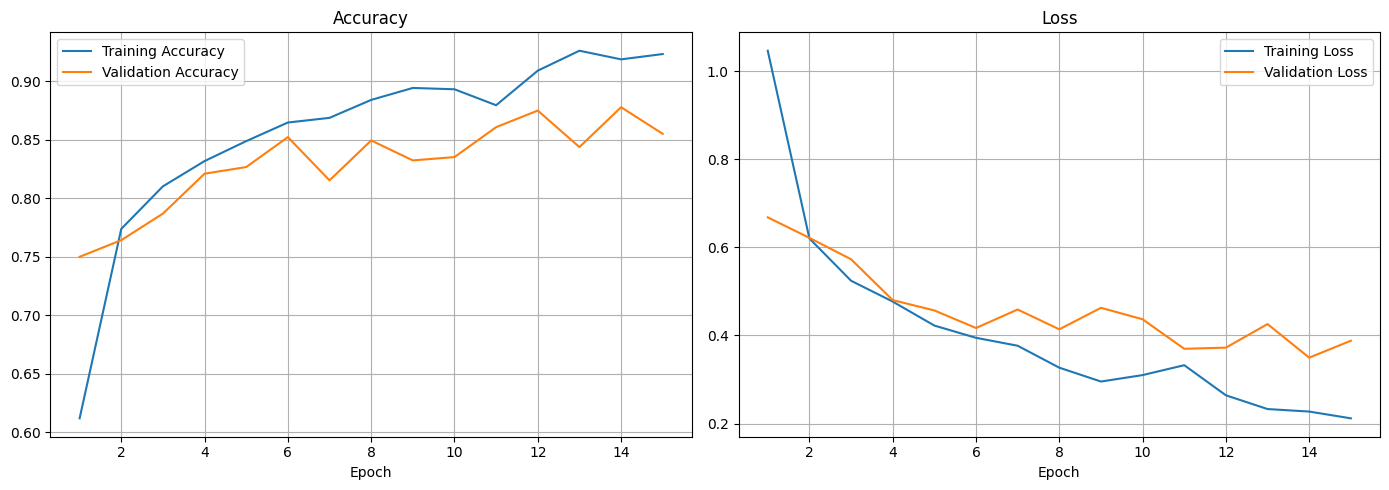

In [12]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──────────────────────────────────────────────────────
axes[0].plot(epochs_range, acc,     label='Training Accuracy')
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# ── Loss ──────────────────────────────────────────────────────────
axes[1].plot(epochs_range, loss,     label='Training Loss')
axes[1].plot(epochs_range, val_loss, label='Validation Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

##### 13. Sauvegarde du modèle
Le modèle est sauvegardé au format `.keras` (format recommandé par Keras 3).

In [13]:
model.save("../model/waste_classifier.keras")
print('Modèle sauvegardé : ../model/waste_classifier.keras')

Modèle sauvegardé : ../model/waste_classifier.keras


##### 14. Prédictions sur le TEST SET

**CORRECTION — Problème 2 du notebook original :**  
Le notebook original faisait `model.predict(val_dataset)` pour extraire les prédictions finales. Or `val_dataset` avait été utilisé pendant le training : le modèle l'avait déjà vu.

**Solution :** On utilise maintenant `test_dataset`, un split **complètement indépendant** que le modèle n'a jamais vu pendant l'entraînement.

> ℹ️ `data_augmentation` est inactive pendant `model.predict()` grâce à l'usage de la Functional API avec `training=True` câblé à la couche d'augmentation. En inférence, Keras utilise `training=False` automatiquement pour toutes les couches — l'augmentation ne s'applique donc pas.

In [14]:
# ── Prédictions ──────────────────────────────────────────────────
predictions = model.predict(test_dataset)
predicted_classes = np.argmax(predictions, axis=1)

# ── Vraies classes ────────────────────────────────────────────────
true_classes = []
for images, labels in test_dataset:
    true_classes.extend(labels.numpy())
true_classes = np.array(true_classes)

print('Classes uniques (true)     :', np.unique(true_classes))
print('Classes uniques (predicted):', np.unique(predicted_classes))
print('Nombre d\'exemples de test  :', len(true_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 711ms/step
Classes uniques (true)     : [0 1 2 3 4 5]
Classes uniques (predicted): [0 1 2 3 4 5]
Nombre d'exemples de test  : 413


##### 15. Sauvegarde des tableaux pour l'évaluation
Ces fichiers seront chargés dans le notebook d'évaluation (`evaluation.ipynb`).

In [15]:
np.save("../model/true_classes.npy",      true_classes)
np.save("../model/predicted_classes.npy", predicted_classes)
np.save("../model/class_names.npy",        class_names)

print('Fichiers sauvegardés :')
print('  ../model/true_classes.npy')
print('  ../model/predicted_classes.npy')
print('  ../model/class_names.npy')

Fichiers sauvegardés :
  ../model/true_classes.npy
  ../model/predicted_classes.npy
  ../model/class_names.npy


---
### ✅ Récapitulatif des corrections appliquées

| # | Problème original | Correction appliquée |
|---|---|---|
| 1 | `Rescaling(1./255)` incompatible avec MobileNetV2 | Remplacé par `mobilenet_v2.preprocess_input` (normalisation -1 à 1) |
| 2 | `val_dataset` utilisé pour training ET évaluation finale | Créé un `test_dataset` indépendant (15% du dataset) |
| 3 | Pas de vrai test split | Split 70% train / 15% val / 15% test |
| 4 | Data augmentation active pendant `predict()` | Functional API + `training=True` câblé → inactif en inférence |